# Exp3: CIFAR-10 测试与加噪验证代码 (Vision Transformer)

本脚本负责从 `vit_model.py` 中加载架构，并加载已经训练好的 ViT 权重，
对纯净的测试集以及含有 20% 椒盐噪声的测试集分别进行推理，对比准确率并可视化结果。

In [1]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 导入独立封装好的 ViT 模型
from vit_model import get_vit_cifar10_model

# 中文显示配置
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'KaiTi']
matplotlib.rcParams['axes.unicode_minus'] = False

BASE_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(BASE_DIR, 'Data')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
WEIGHT_PATH = os.path.join(RESULT_DIR, 'vit_b_16_cifar10.pth')

BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

## 1. 加噪函数与数据加载

In [2]:
class AddSaltPepperNoise(object):
    def __init__(self, salt_prob=0.1, pepper_prob=0.1):
        self.salt_prob = salt_prob
        self.pepper_prob = pepper_prob

    def __call__(self, img):
        img_arr = np.array(img)
        noise = np.random.rand(img_arr.shape[0], img_arr.shape[1])
        salt_mask = noise < self.salt_prob
        pepper_mask = (noise >= self.salt_prob) & (noise < self.salt_prob + self.pepper_prob)
        img_arr[salt_mask] = 255
        img_arr[pepper_mask] = 0
        return Image.fromarray(img_arr)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

test_clean_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_noisy_transforms = transforms.Compose([
    AddSaltPepperNoise(salt_prob=0.1, pepper_prob=0.1),
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

print("加载测试集...")
test_clean_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=False, transform=test_clean_transforms)
test_noisy_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=False, transform=test_noisy_transforms)

clean_loader = DataLoader(test_clean_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
noisy_loader = DataLoader(test_noisy_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

加载测试集...


## 2. 加载训练好的 ViT 模型权重

In [3]:
print("\n从 vit_model.py 加载模型架构并载入权重...")
model = get_vit_cifar10_model(pretrained=False)

if os.path.exists(WEIGHT_PATH):
    model.load_state_dict(torch.load(WEIGHT_PATH, map_location=device))
    print("[OK] 成功载入权重: ", WEIGHT_PATH)
else:
    print("[Warning] 未找到权重文件，将使用随机权重！请先运行 exp3_train.py")

model = model.to(device)


从 vit_model.py 加载模型架构并载入权重...
[OK] 成功载入权重:  d:\Vscode\Project\DIP-Experiment\Exp3\results\vit_b_16_cifar10.pth


## 3. 测试与对比 (Clean vs Noisy)

In [4]:
def eval_loader(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

print("\n开始评测...")
clean_acc = eval_loader(model, clean_loader, device)
noisy_acc = eval_loader(model, noisy_loader, device)

print("-" * 40)
print(f"  纯净测试集准确率 (Clean Acc) : {clean_acc:.2f}%")
print(f"  噪声测试集准确率 (Noisy Acc) : {noisy_acc:.2f}%")
print("-" * 40)


开始评测...
----------------------------------------
  纯净测试集准确率 (Clean Acc) : 94.23%
  噪声测试集准确率 (Noisy Acc) : 31.50%
----------------------------------------


## 4. 预测结果可视化展示

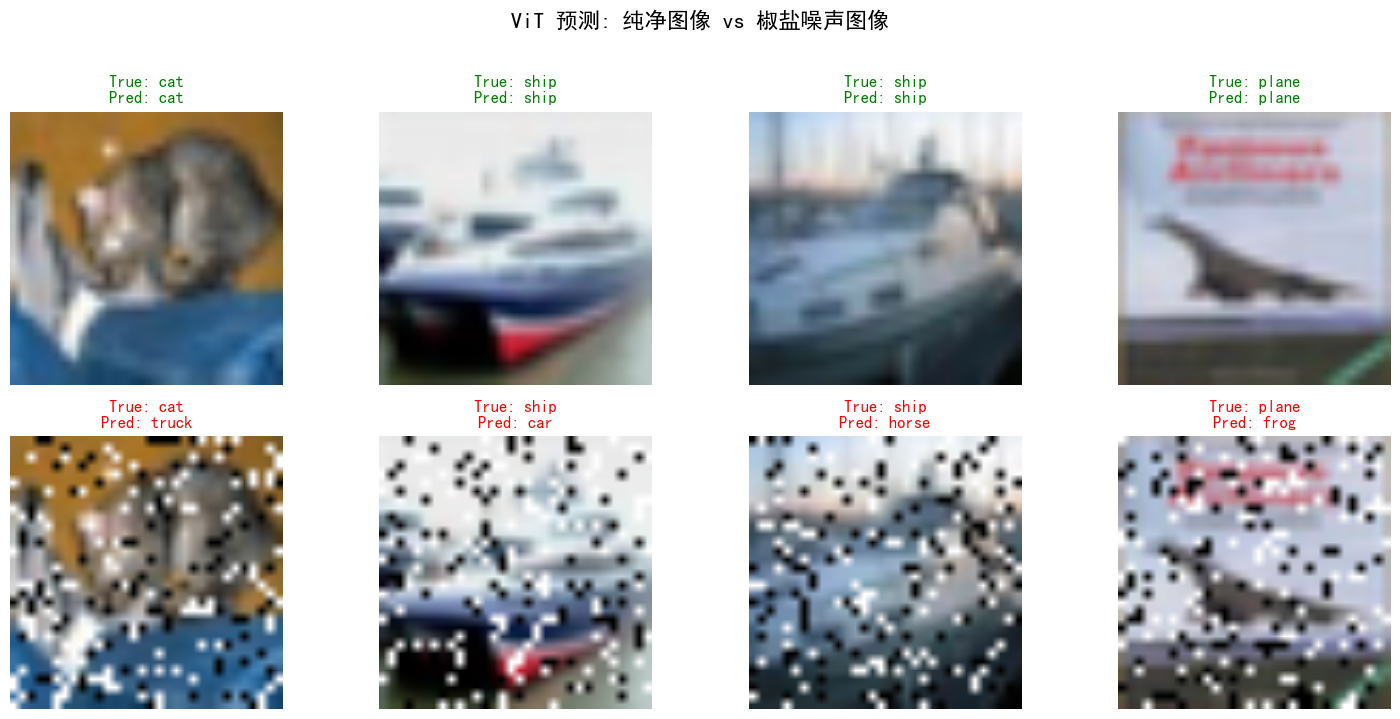

In [5]:
def denormalize(tensor_img):
    img = tensor_img.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

clean_images, clean_labels = next(iter(clean_loader))
noisy_images, noisy_labels = next(iter(noisy_loader))

num_show = 4
clean_images = clean_images[:num_show].to(device)
noisy_images = noisy_images[:num_show].to(device)
labels = clean_labels[:num_show].cpu().numpy()

model.eval()
with torch.no_grad():
    clean_preds = model(clean_images).max(1)[1].cpu().numpy()
    noisy_preds = model(noisy_images).max(1)[1].cpu().numpy()

fig, axes = plt.subplots(2, num_show, figsize=(15, 7))
fig.suptitle('ViT 预测: 纯净图像 vs 椒盐噪声图像', fontsize=16, fontweight='bold', y=1.02)

for i in range(num_show):
    # 纯净图
    ax = axes[0, i]
    ax.imshow(denormalize(clean_images[i]))
    ax.axis('off')
    color = 'green' if clean_preds[i] == labels[i] else 'red'
    ax.set_title(f"True: {classes[labels[i]]}\nPred: {classes[clean_preds[i]]}", color=color)
    
    # 噪声图
    ax = axes[1, i]
    ax.imshow(denormalize(noisy_images[i]))
    ax.axis('off')
    color = 'green' if noisy_preds[i] == labels[i] else 'red'
    ax.set_title(f"True: {classes[labels[i]]}\nPred: {classes[noisy_preds[i]]}", color=color)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'exp3_predictions_comparison.png'))
plt.show()